#1: Training model recognition table

In [3]:
# ── Imports ───────────────────────────────────────────────
import torch
import random
import numpy as np
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
import timm

import os, gc, time, shutil, subprocess, json
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

/Users/macbookpro14m1pro/Desktop/RagTable/python/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")
ds1_img  = BASE / "table_segmentation_1/data/images"
ds1_mask = BASE / "table_segmentation_1/data/masks"
ds2_mask = BASE / "table_segmentation_2/data/masks"
ds3_mask = BASE / "table_segmentation_3/data/masks"

# Gom tất cả IDs có mask
all_mask_ids = set()
for mask_dir in [ds1_mask, ds2_mask, ds3_mask]:
    for f in mask_dir.glob("*_row.png"):
        all_mask_ids.add(f.stem.replace("_row", ""))

# IDs có image
all_img_ids = set(f.stem for f in ds1_img.glob("*.png"))

print(f"Total mask IDs: {len(all_mask_ids):,}")
print(f"Total image IDs: {len(all_img_ids):,}")
print(f"IDs có cả image lẫn mask: {len(all_mask_ids & all_img_ids):,}")
print(f"IDs có mask nhưng không có image: {len(all_mask_ids - all_img_ids):,}")
print(f"IDs có image nhưng không có mask: {len(all_img_ids - all_mask_ids):,}")

Total mask IDs: 30,000
Total image IDs: 30,000
IDs có cả image lẫn mask: 30,000
IDs có mask nhưng không có image: 0
IDs có image nhưng không có mask: 0


In [36]:
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# Đường dẫn cơ sở và các thư mục mask
BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")
mask_dirs = [BASE / "table_segmentation_1/data/masks",
             BASE / "table_segmentation_2/data/masks",
             BASE / "table_segmentation_3/data/masks"]

# Lấy tất cả ID từ các file mask (như bạn đã làm)
all_ids = set()
for mask_dir in mask_dirs:
    for f in mask_dir.glob("*_row.png"):
        all_ids.add(f.stem.replace("_row", ""))

total = len(all_ids)
has_header = 0
has_span = 0

# Duyệt qua từng ID, kiểm tra mask header và span
# Lưu ý: các file mask có thể nằm trong bất kỳ mask_dir nào, nên ta cần tìm đúng đường dẫn.
# Để tiện, ta sẽ tạo một dict ánh xạ từ ID đến thư mục chứa mask của nó (dựa vào một kênh bất kỳ, ví dụ _row.png)
id_to_dir = {}
for mask_dir in mask_dirs:
    for f in mask_dir.glob("*_row.png"):
        sample_id = f.stem.replace("_row", "")
        id_to_dir[sample_id] = mask_dir

# Bây giờ duyệt tất cả ID để thống kê
for sample_id in tqdm(sorted(all_ids), desc="Đang thống kê"):
    mask_dir = id_to_dir.get(sample_id)
    if mask_dir is None:
        print(f"Không tìm thấy thư mục cho ID {sample_id}, bỏ qua.")
        continue

    # Đọc mask col_header, row_header và span
    col_header_path = mask_dir / f"{sample_id}_col_header.png"
    row_header_path = mask_dir / f"{sample_id}_row_header.png"
    span_path = mask_dir / f"{sample_id}_span.png"

    try:
        col_header = np.array(Image.open(col_header_path))
        row_header = np.array(Image.open(row_header_path))
        span = np.array(Image.open(span_path))
    except FileNotFoundError as e:
        print(f"Thiếu file cho {sample_id}: {e}")
        continue

    # Kiểm tra header: nếu bất kỳ mask col_header hoặc row_header có pixel > 0
    if np.any(col_header > 0) or np.any(row_header > 0):
        has_header += 1

    # Kiểm tra span
    if np.any(span > 0):
        has_span += 1

print(f"\nTổng số mẫu: {total}")
print(f"Số mẫu có header (col_header hoặc row_header): {has_header} ({100*has_header/total:.1f}%)")
print(f"Số mẫu có ô gộp (span): {has_span} ({100*has_span/total:.1f}%)")

Đang thống kê:  33%|███▎      | 9900/30000 [00:06<00:13, 1441.68it/s]

Thiếu file cho sample_009723: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_3/data/masks/sample_009723_col_header.png'
Thiếu file cho sample_009725: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_3/data/masks/sample_009725_col_header.png'
Thiếu file cho sample_009726: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_3/data/masks/sample_009726_col_header.png'
Thiếu file cho sample_009727: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_2/data/masks/sample_009727_span.png'
Thiếu file cho sample_009728: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_2/data/masks/sample_009728_span.png'
Thiếu file cho sample_009729: [Errno 2] No such file or direct

Đang thống kê:  35%|███▌      | 10573/30000 [00:07<00:12, 1581.86it/s]

Thiếu file cho sample_010252: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_3/data/masks/sample_010252_col_header.png'


Đang thống kê:  36%|███▋      | 10892/30000 [00:07<00:12, 1556.02it/s]

...

Thiếu file cho sample_022799: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_2/data/masks/sample_022799_span.png'
Thiếu file cho sample_022834: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_2/data/masks/sample_022834_row_header.png'
Thiếu file cho sample_022835: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_2/data/masks/sample_022835_row_header.png'
Thiếu file cho sample_022836: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_2/data/masks/sample_022836_row_header.png'
Thiếu file cho sample_022837: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_2/data/masks/sample_022837_col_header.png'
Thiếu file cho sample_022838: [Errno 2] No such file or 

Đang thống kê:  78%|███████▊  | 23546/30000 [00:15<00:05, 1225.36it/s]

Thiếu file cho sample_023310: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_2/data/masks/sample_023310_col_header.png'
Thiếu file cho sample_023515: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_2/data/masks/sample_023515_col_header.png'


Đang thống kê: 100%|██████████| 30000/30000 [00:20<00:00, 1484.92it/s]


Tổng số mẫu: 30000
Số mẫu có header (col_header hoặc row_header): 27902 (93.0%)
Số mẫu có ô gộp (span): 12648 (42.2%)


In [5]:
# ── Config ────────────────────────────────────────────────
BATCH_SIZE = 8
IMG_SIZE = 384
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Đường dẫn ─────────────────────────────────────────────
BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")

IMG_DIR = BASE / "table_segmentation_1/data/images"

MASK_DIR_DILATED = BASE / "masks_dilated"

# Build lookup: sid → mask_dir
mask_dir_lookup = {}
for f in MASK_DIR_DILATED.glob("*_row.png"):
    sid = f.stem.replace("_row", "")
    mask_dir_lookup[sid] = MASK_DIR_DILATED

all_ids = sorted(mask_dir_lookup.keys())

print(f"Images:      {len(list(IMG_DIR.glob('*.png'))):,}")
print(f"Mask lookup: {len(mask_dir_lookup):,}")
print(f"Total IDs:   {len(all_ids):,}")
print(f"Device:      {device}")
# ── CELL 2: Dataset ───────────────────────────────────────
class TableDataset(Dataset):
    MASK_TYPES = ["row", "col", "col_header", "row_header", "span"]

    def __init__(self, sample_ids, augment=False):
        self.sample_ids = sample_ids
        self.augment    = augment

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sid = self.sample_ids[idx]
    
        img  = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
        mask_dir = mask_dir_lookup[sid]  # tự động chọn đúng thư mục
    
        masks = {}
        for mtype in self.MASK_TYPES:
            p = mask_dir / f"{sid}_{mtype}.png"
            masks[mtype] = Image.open(p).convert("L") if p.exists() \
                else Image.fromarray(np.zeros((IMG_SIZE, IMG_SIZE), np.uint8))
    
        if self.augment:
            img, masks = self._augment(img, masks)

        img = TF.resize(img, (IMG_SIZE, IMG_SIZE), 
                    interpolation=TF.InterpolationMode.BILINEAR)
        masks = {k: TF.resize(v, (IMG_SIZE, IMG_SIZE),
                    interpolation=TF.InterpolationMode.NEAREST)
             for k, v in masks.items()}
    
        img_t  = TF.to_tensor(img)
        mask_t = torch.cat([
            (TF.to_tensor(masks[m]) > 0.5).float()
            for m in self.MASK_TYPES
        ], dim=0)
        return {"image": img_t, "masks": mask_t, "sample_id": sid}

    def _augment(self, img, masks):
        all_imgs = [img] + list(masks.values())
    
        # Rotate nhiều hơn
        if random.random() > 0.5:
            angle = random.uniform(-3, 3)  
            all_imgs = [TF.rotate(i, angle) for i in all_imgs]
    
        # Horizontal flip (giữ)
        if random.random() > 0.5:
            all_imgs = [TF.hflip(i) for i in all_imgs]
    
        # Brightness/contrast (giữ)
        if random.random() > 0.5:
            all_imgs[0] = TF.adjust_brightness(all_imgs[0], random.uniform(0.7, 1.3))
            all_imgs[0] = TF.adjust_contrast(all_imgs[0], random.uniform(0.7, 1.3))
    
        img = all_imgs[0]
        for k, key in enumerate(masks.keys()):
            masks[key] = all_imgs[k+1]
        return img, masks

# Split train/val
random.seed(42)
random.shuffle(all_ids)
n_val     = int(len(all_ids) * 0.1)
train_ids = all_ids[:-n_val]
val_ids   = all_ids[-n_val:]

train_ds = TableDataset(train_ids, augment=True)
val_ds   = TableDataset(val_ids,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=0)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# Verify 1 batch
batch = next(iter(train_loader))
print(f"Image shape: {batch['image'].shape}")
print(f"Masks shape: {batch['masks'].shape}")
print(f"Masks unique: {batch['masks'].unique().tolist()}")

Images:      30,000
Mask lookup: 30,000
Total IDs:   30,000
Device:      cpu
Train: 27,000 | Val: 3,000
Train batches: 3375 | Val batches: 375
Image shape: torch.Size([8, 3, 384, 384])
Masks shape: torch.Size([8, 5, 384, 384])
Masks unique: [0.0, 1.0]


Sample: sample_000445
Image size: (256, 256)


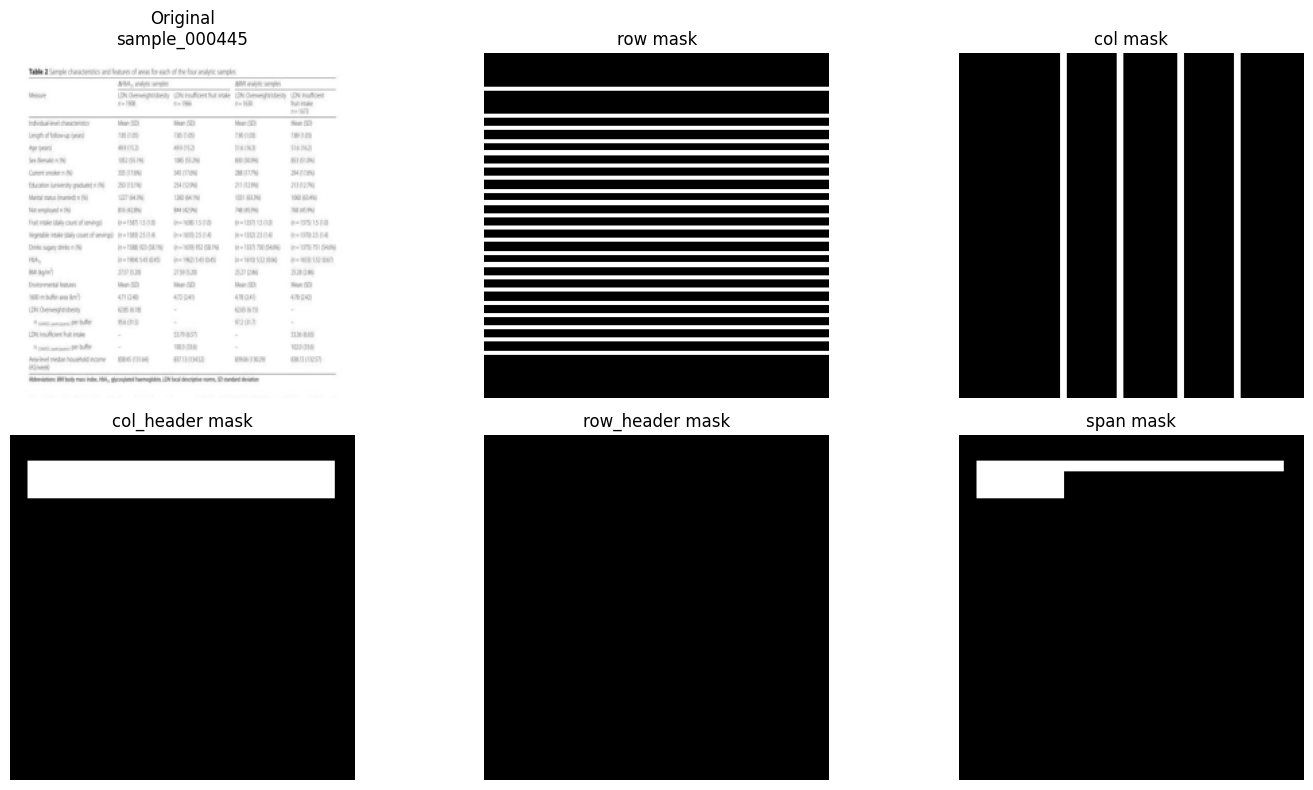


📊 Mask stats:
  row         : 25.8% white pixels
  col         : 7.8% white pixels
  col_header  : 9.7% white pixels
  row_header  : 0.0% white pixels
  span        : 4.8% white pixels


In [8]:
# Lấy 1 sample ngẫu nhiên
sample_ids = [f.stem for f in sorted(IMG_DIR.glob("*.png"))]
sid = random.choice(sample_ids)
print(f"Sample: {sid}")

# Load ảnh
img = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
print(f"Image size: {img.size}")

# Load và visualize 5 masks
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
mask_names = ["row", "col", "col_header", "row_header", "span"]

axes[0, 0].imshow(img)
axes[0, 0].set_title(f"Original\n{sid}")
axes[0, 0].axis("off")

for i, mtype in enumerate(mask_names):
    ax = axes[(i+1)//3, (i+1)%3]
    p  = mask_dir_lookup[sid] / f"{sid}_{mtype}.png"  
    if p.exists():
        mask = Image.open(p).convert("L")
        ax.imshow(mask, cmap="gray")
        ax.set_title(f"{mtype} mask")
    else:
        ax.set_title(f"{mtype} — NOT FOUND")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Thống kê masks
print("\n📊 Mask stats:")
for mtype in mask_names:
    p = mask_dir_lookup[sid] / f"{sid}_{mtype}.png" 
    if p.exists():
        mask_arr = np.array(Image.open(p).convert("L"))
        white_pct = (mask_arr > 128).sum() / mask_arr.size * 100
        print(f"  {mtype:<12}: {white_pct:.1f}% white pixels")
    else:
        print(f"  {mtype:<12}: NOT FOUND")

In [9]:
BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")

# Tạo folder mới
NEW_MASK_DIR = BASE / "masks_dilated"

mask_dir_lookup = {
    f.stem.replace("_row", ""): NEW_MASK_DIR
    for f in NEW_MASK_DIR.glob("*_row.png")
}

all_ids = sorted(mask_dir_lookup.keys())
print(f"✅ mask_dir_lookup → {NEW_MASK_DIR}")
print(f"Total IDs in new lookup: {len(all_ids):,}")
print(f"Total masks: {len(list(NEW_MASK_DIR.glob('*.png'))):,}")

✅ mask_dir_lookup → /Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/masks_dilated
Total IDs in new lookup: 30,000
Total masks: 149,826


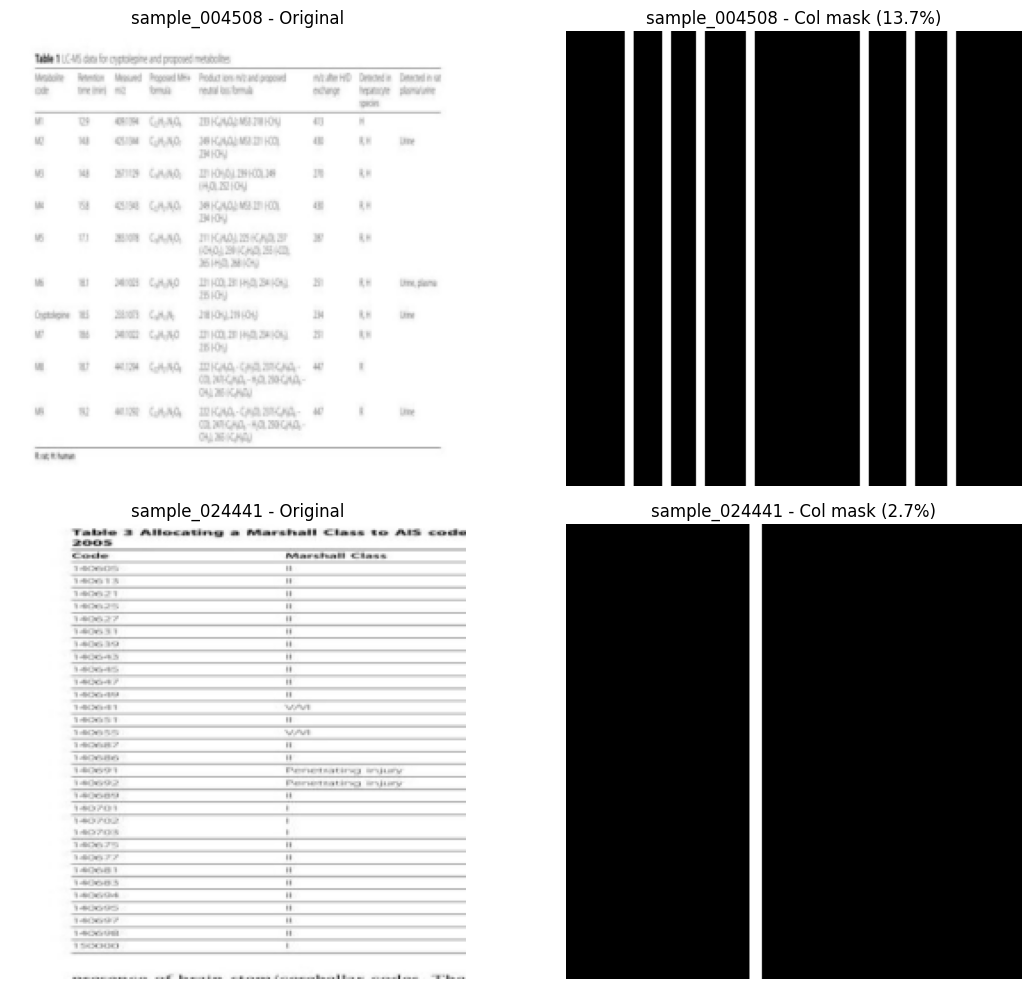

In [11]:
suspicious = ["sample_004508", "sample_024441"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, sid in enumerate(suspicious):
    # Ảnh gốc
    img = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"{sid} - Original")
    axes[i, 0].axis("off")

    # Col mask sau dilate
    mask = Image.open(NEW_MASK_DIR / f"{sid}_col.png").convert("L")
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"{sid} - Col mask ({(np.array(mask)>128).mean()*100:.1f}%)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [6]:
# ── CELL 3: EfficientNet-B4 + UNet Decoder ───────────────
class EfficientUNet(nn.Module):
    def __init__(self, out_ch=5, pretrained=True):
        super().__init__()

        # ── Encoder: EfficientNet-B4 ──────────────────
        self.encoder = timm.create_model(
            "efficientnet_b4",
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3, 4),
        )
        # EfficientNet-B4 channel sizes: 24, 32, 56, 160, 448
        enc_chs = self.encoder.feature_info.channels() 

        # ── Bottleneck ────────────────────────────────
        self.bottleneck = nn.Sequential(
            nn.Conv2d(enc_chs[4], 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )

        # ── Decoder blocks ────────────────────────────
        self.dec4 = self._dec_block(256 + enc_chs[3], 128)
        self.dec3 = self._dec_block(128 + enc_chs[2], 64)
        self.dec2 = self._dec_block(64  + enc_chs[1], 32)
        self.dec1 = self._dec_block(32  + enc_chs[0], 16)
        self.dec0 = self._dec_block(16, 16)  

        # ── Output ────────────────────────────────────
        self.out_conv = nn.Conv2d(16, out_ch, 1)

    def _dec_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        feats = self.encoder(x)  # [s0,s1,s2,s3,s4]
        s0, s1, s2, s3, s4 = feats

        # Bottleneck
        b = self.bottleneck(s4)

        # Decoder + skip connections
        x = F.interpolate(b,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec4(torch.cat([x, s3], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec3(torch.cat([x, s2], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec2(torch.cat([x, s1], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec1(torch.cat([x, s0], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec0(x)

        return self.out_conv(x)


# ── Verify ────────────────────────────────────────────────
model = EfficientUNet(out_ch=5, pretrained=False).to(device)
dummy = torch.randn(2, 3, 384, 384).to(device)
with torch.no_grad():
    out = model(dummy)

total = sum(p.numel() for p in model.parameters())
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}")
print(f"Params: {total/1e6:.1f}M")
print(f"Output size match: {out.shape[-2:] == torch.Size([384, 384])}")

Input:  torch.Size([2, 3, 384, 384])
Output: torch.Size([2, 5, 384, 384])
Params: 19.2M
Output size match: True


In [ ]:
model = timm.create_model('efficientnet_b4', features_only=True)
for f in model.feature_info:
    print(f)

{'stage': 1, 'reduction': 2, 'module': 'blocks.0', 'num_chs': 24, 'index': 0}
{'stage': 2, 'reduction': 4, 'module': 'blocks.1', 'num_chs': 32, 'index': 1}
{'stage': 3, 'reduction': 8, 'module': 'blocks.2', 'num_chs': 56, 'index': 2}
{'stage': 5, 'reduction': 16, 'module': 'blocks.4', 'num_chs': 160, 'index': 3}
{'stage': 7, 'reduction': 32, 'module': 'blocks.6', 'num_chs': 448, 'index': 4}


In [9]:
def boundary_loss(pred, target, kernel_size=3):
    """Penalize lỗi tại boundary nhiều hơn"""
    pad = kernel_size // 2
    # Tính boundary của target bằng erosion
    eroded = -F.max_pool2d(-target, kernel_size, stride=1, padding=pad)
    boundary = target - eroded  # chỉ giữ lại viền

    bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
    
    # Tăng weight tại vùng boundary
    weight = 1.0 + 5.0 * boundary
    return (bce * weight).mean()

class DiceFocalLoss(nn.Module):
    def __init__(self, focal_weight=0.4, boundary_weight=0.2, alpha=0.75, gamma=2.0):
        super().__init__()
        self.focal_w = focal_weight
        self.boundary_w = boundary_weight
        self.dice_w     = 1 - focal_weight - boundary_weight
        self.alpha = alpha
        self.gamma = gamma
        # Trọng số: [row, col, col_header, row_header, span]
        self.channel_weights = torch.tensor([2.0, 2.0, 1.0, 4.0, 6.0])

    def forward(self, pred, target):
        weights = self.channel_weights.to(pred.device)
        total = 0
        for i in range(pred.shape[1]):
            p = pred[:, i:i+1]
            t = target[:, i:i+1]
            
            # 1. Tính Focal Loss (xử lý viền mỏng)
            bce = F.binary_cross_entropy_with_logits(p, t, reduction='none')
            pt = torch.exp(-bce)
            focal_loss = (self.alpha * (1 - pt) ** self.gamma * bce).mean()
            
            # 2. Tính Dice Loss (xử lý IoU tổng thể)
            pred_sig = torch.sigmoid(p).reshape(-1)
            t_flat = t.reshape(-1)
            inter = (pred_sig * t_flat).sum()
            eps = 1e-6
            dice_loss = 1 - (2*inter+eps)/(pred_sig.sum()+t_flat.sum()+eps)
            b_loss = boundary_loss(p, t)
            
            # 3. Tổng hợp lại có nhân trọng số channel
            total += weights[i] * (
                self.focal_w * focal_loss +
                self.dice_w  * dice_loss  +
                self.boundary_w * b_loss
            )
            
        return total / pred.shape[1]
        
def compute_miou(pred_logits, target, threshold=0.5, thresholds=None):
    names = ["row","col","col_header","row_header","span"]
    ious  = {}
    for i, name in enumerate(names):
        thr  = thresholds[name] if thresholds else threshold
        pred = (torch.sigmoid(pred_logits[:, i]) > thr).float()
        p    = pred.reshape(-1)
        t    = target[:, i].reshape(-1)
        inter = (p*t).sum()
        union = (p+t-p*t).sum()
        ious[name] = (inter/union).item() if union >= 1 else float("nan")
    valid        = [v for v in ious.values() if not np.isnan(v)]
    ious["mean"] = np.mean(valid) if valid else 0.0
    return ious

def find_best_thresholds(model, loader, device):
    model.eval()
    all_preds = {i: [] for i in range(5)}
    all_masks  = {i: [] for i in range(5)}
    with torch.no_grad():
        for batch in loader:
            imgs, masks = batch["image"].to(device), batch["masks"].to(device)
            preds = torch.sigmoid(model(imgs))
            for i in range(5):
                all_preds[i].append(preds[:,i].cpu())
                all_masks[i].append(masks[:,i].cpu())
    names = ["row","col","col_header","row_header","span"]
    best_thresholds = {}
    for i, name in enumerate(names):
        p_all = torch.cat(all_preds[i]).reshape(-1).numpy()
        t_all = torch.cat(all_masks[i]).reshape(-1).numpy()
        best_iou, best_thr = 0, 0.5
        for thr in np.arange(0.1, 0.9, 0.02):
            p_bin = (p_all > thr).astype(float)
            inter = (p_bin * t_all).sum()
            union = (p_bin + t_all - p_bin * t_all).sum()
            iou   = inter / union if union > 0 else 0
            if iou > best_iou:
                best_iou, best_thr = iou, thr
        best_thresholds[name] = best_thr
        print(f"  {name}: best_thr={best_thr:.2f} → IoU={best_iou:.4f}")
    return best_thresholds

scaler = torch.amp.GradScaler('cuda')

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0
    for batch in loader:
        imgs, masks = batch["image"].to(device), batch["masks"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss = criterion(model(imgs), masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total += loss.item()
    return total / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total    = 0
    all_ious = {n:[] for n in ["row","col","col_header","row_header","span"]}
    with torch.no_grad():
        for batch in loader:
            imgs, masks = batch["image"].to(device), batch["masks"].to(device)
            preds = model(imgs)
            total += criterion(preds, masks).item()
            for name, val in compute_miou(preds, masks).items():
                if name != "mean" and not np.isnan(val):
                    all_ious[name].append(val)
    avg_ious         = {n: np.mean(v) if v else 0.0 for n,v in all_ious.items()}
    avg_ious["mean"] = np.mean(list(avg_ious.values()))
    return total/len(loader), avg_ious

print("✅ Hàm đã định nghĩa xong!")

✅ Hàm đã định nghĩa xong!


/var/folders/pc/wtsv3z5s0j5bx006fg66b6mr0000gn/T/ipykernel_75124/878121478.py:97: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = torch.amp.GradScaler('cuda')


In [ ]:
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
gc.collect()
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True

# ── Config ────────────────────────────────────────────────
LR_FT     = 2e-6
EPOCHS_FT = 80    
patience  = 15    
CKPT_DIR   = Path("/kaggle/working/checkpoints_effb4_ft")
CKPT_DIR.mkdir(exist_ok=True)
BACKUP_DIR = Path("/kaggle/working/checkpoint_backup_ft")
BACKUP_DIR.mkdir(exist_ok=True)

scaler = torch.amp.GradScaler('cuda')

# ── DataLoader ────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# ── Load best model ───────────────────────────────────────
CKPT_SRC = Path("/kaggle/input/table-seg-checkpoints-v2")
ckpt = torch.load(CKPT_SRC / "best_model.pt", map_location=device, weights_only=False)
model = EfficientUNet(out_ch=5, pretrained=False).to(device)
model.load_state_dict(ckpt["model"])
print(f"✅ Loaded epoch={ckpt['epoch']} | mIoU={ckpt['best_miou']:.4f}")

# ── Loss ──────────────────────────────────────────────────
criterion = DiceFocalLoss(focal_weight=0.4, boundary_weight=0.2, alpha=0.75, gamma=2.0).to(device)

# ── Optimizer ─────────────────────────────────────────────
optimizer = AdamW([
    {"params": model.encoder.parameters(),    "lr": LR_FT * 0.3},
    {"params": model.bottleneck.parameters(), "lr": LR_FT},
    {"params": model.dec4.parameters(),       "lr": LR_FT},
    {"params": model.dec3.parameters(),       "lr": LR_FT},
    {"params": model.dec2.parameters(),       "lr": LR_FT},
    {"params": model.dec1.parameters(),       "lr": LR_FT},
    {"params": model.dec0.parameters(),       "lr": LR_FT},
    {"params": model.out_conv.parameters(),   "lr": LR_FT},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-8
)

best_miou  = ckpt["best_miou"]
history_ft = ckpt["history"]
no_improve = 0 
START      = ckpt["epoch"] + 1
END        = START + 30

# ── Tạo dataset backup TRƯỚC khi train ───────────────────
meta_path = BACKUP_DIR / "dataset-metadata.json"
with open(meta_path, "w") as f:
    json.dump({
        "title": "table-seg-checkpoints-v2",
        "id": "tiinh123/table-seg-checkpoints-v2",
        "licenses": [{"name": "CC0-1.0"}]
    }, f)

# Copy checkpoint gốc vào backup rồi create dataset
check = subprocess.run([
    "kaggle", "datasets", "files",
    "tiinh123/table-seg-checkpoints-v2"
], capture_output=True, text=True)

if check.returncode == 0:
    print(f"✅ Dataset đã tồn tại, sẵn sàng backup")
else:
    shutil.copy2(CKPT_SRC / "best_model.pt", BACKUP_DIR / "best_model.pt")
    result = subprocess.run([
        "kaggle", "datasets", "create",
        "-p", str(BACKUP_DIR),
        "--dir-mode", "tar"
    ], capture_output=True, text=True)
    if "being created" in result.stdout:
        print(f"✅ Dataset created!")
    else:
        print(f"⚠️ {result.stdout[:100]}")

print(f"\nFine-tuning epoch {START} → {END-1} | lr={LR_FT}\n")

# ── Training loop ─────────────────────────────────────────
for epoch in range(START, END):
    t          = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_ious = validate(model, val_loader, criterion, device)
    scheduler.step()
    miou = val_ious["mean"]

    history_ft["train_loss"].append(train_loss)
    history_ft["val_loss"].append(val_loss)
    history_ft["val_miou"].append(miou)

    print(f"Epoch {epoch:2d} | Train={train_loss:.4f} Val={val_loss:.4f} mIoU={miou:.4f} | {time.time()-t:.0f}s")

    if epoch % 5 == 0:
        print(f"  row={val_ious['row']:.3f} | col={val_ious['col']:.3f} | "
              f"hdr={val_ious['col_header']:.3f} | rhdr={val_ious['row_header']:.3f} | span={val_ious['span']:.3f}")

    # Save checkpoint local
    ckpt_new = {
        "epoch":      epoch,
        "model":      model.state_dict(),
        "optimizer":  optimizer.state_dict(),
        "scheduler":  scheduler.state_dict(),
        "history":    history_ft,
        "best_miou":  best_miou,
        "no_improve": no_improve,
    }
    torch.save(ckpt_new, CKPT_DIR / "last_checkpoint.pt")

    # Backup mỗi 5 epoch
    if epoch % 5 == 0:
        torch.save(ckpt_new, CKPT_DIR / f"checkpoint_epoch{epoch}.pt")
        shutil.copy2(CKPT_DIR / "last_checkpoint.pt", BACKUP_DIR / "last_checkpoint.pt")
        result = subprocess.run([
            "kaggle", "datasets", "version",
            "-p", str(BACKUP_DIR),
            "-m", f"epoch{epoch}-miou{miou:.4f}", 
            "--dir-mode", "tar"
        ], capture_output=True, text=True)

        if "Upload successful" in result.stderr or "successful" in result.stdout.lower():
            print(f"  💾 Saved + ☁️ Backed up epoch{epoch}")
        else:
            print(f"  ⚠️ Backup: {result.stdout[:80]}")

    # Best model
    if miou > best_miou:
        best_miou  = miou
        no_improve = 0
        torch.save(ckpt_new, CKPT_DIR / "best_model.pt")
        shutil.copy2(CKPT_DIR / "best_model.pt", BACKUP_DIR / "best_model.pt")

        result = subprocess.run([
            "kaggle", "datasets", "version",
            "-p", str(BACKUP_DIR),
            "-m", f"BEST-epoch{epoch}-miou{best_miou:.4f}",
            "--dir-mode", "tar"
        ], capture_output=True, text=True)

        if "Upload successful" in result.stderr or "successful" in result.stdout.lower():
            print(f"  ✅ Best saved + backed up (mIoU={best_miou:.4f})")
        else:
            print(f"  ⚠️ Backup status unknown: {result.stdout[:100]}")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"⛔ Early stopping epoch {epoch}")
            break

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_ft["train_loss"], label="Train")
axes[0].plot(history_ft["val_loss"],   label="Val")
axes[0].set_title("Fine-tune Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_ft["val_miou"], color="green", label="mIoU")
axes[1].axhline(0.80, color="red", linestyle="--", label="Target 0.80")
axes[1].set_title("Fine-tune mIoU"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n✅ Fine-tune done! Best mIoU: {best_miou:.4f}")

Train batches: 3375 | Val batches: 375
✅ Loaded epoch=92 | mIoU=0.7962
✅ Dataset đã tồn tại, sẵn sàng backup

Fine-tuning epoch 93 → 122 | lr=2e-06

Epoch 93 | Train=0.2879 Val=0.7665 mIoU=0.7869 | 878s
Epoch 94 | Train=0.2877 Val=0.6298 mIoU=0.7849 | 776s
Epoch 95 | Train=0.2885 Val=0.7199 mIoU=0.7815 | 776s
  row=0.795 | col=0.770 | hdr=0.892 | rhdr=0.728 | span=0.723
  💾 Saved + ☁️ Backed up epoch95
Epoch 96 | Train=0.2850 Val=0.4032 mIoU=0.7882 | 775s
Epoch 97 | Train=0.2875 Val=0.3549 mIoU=0.7941 | 776s
Epoch 98 | Train=0.2862 Val=0.4154 mIoU=0.7860 | 776s
Epoch 99 | Train=0.2839 Val=0.9072 mIoU=0.7888 | 776s
Epoch 100 | Train=0.2895 Val=0.4168 mIoU=0.7876 | 776s
  row=0.797 | col=0.775 | hdr=0.896 | rhdr=0.740 | span=0.730
  💾 Saved + ☁️ Backed up epoch100
Epoch 101 | Train=0.2822 Val=0.3522 mIoU=0.7935 | 775s
Epoch 102 | Train=0.2859 Val=0.3561 mIoU=0.7917 | 779s
Epoch 103 | Train=0.2829 Val=0.3929 mIoU=0.7881 | 776s
Epoch 104 | Train=0.2883 Val=0.3548 mIoU=0.7927 | 775s


In [14]:
# 1. Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATH = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/table-seg-checkpoints-v2/best_model_v2.pt")

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model_eval = EfficientUNet(out_ch=5, pretrained=False).to(device)
model_eval.load_state_dict(ckpt["model"])
model_eval.eval()

print(f"✅ Đã load Model từ epoch {ckpt['epoch']} (mIoU cũ: {ckpt['best_miou']:.4f})")

if 'history' in ckpt:
    val_miou_history = ckpt['history']['val_miou']
    print(f"📈 Số lượng Epoch đã lưu trong lịch sử: {len(val_miou_history)}")
    print(f"📊 5 Epoch cuối cùng: {val_miou_history[-5:]}")
    
    # Tìm giá trị lớn nhất trong lịch sử xem có khớp 0.7962 không
    max_in_history = max(val_miou_history)
    print(f"🏆 Giá trị cao nhất trong lịch sử: {max_in_history:.4f}")

# 2. Chuẩn bị DataLoader (Sử dụng val_ds đã có của bạn)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

✅ Đã load Model từ epoch 92 (mIoU cũ: 0.7962)
📈 Số lượng Epoch đã lưu trong lịch sử: 92
📊 5 Epoch cuối cùng: [0.7914414340467895, 0.7906019581687095, 0.791963967882408, 0.7914080008316677, 0.7974435706013603]
🏆 Giá trị cao nhất trong lịch sử: 0.7974


In [15]:
# Hàm load model
def load_model(path, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model = EfficientUNet(out_ch=5, pretrained=False).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model, ckpt

# Đường dẫn
best_path = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/table-seg-checkpoints-v2/best_model_v2.pt")
last_path = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/table-seg-checkpoints-v2/checkpoint_epoch35.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model_best, ckpt_best = load_model(best_path, device)
print(f"✅ Load best model epoch {ckpt_best['epoch']} (mIoU: {ckpt_best['best_miou']:.4f})")

if last_path.exists():
    model_last, ckpt_last = load_model(last_path, device)
    print(f"✅ Load last model epoch {ckpt_last['epoch']}")
else:
    print("⚠️ Last checkpoint not found, using best model")
    model_last = model_best

✅ Load best model epoch 92 (mIoU: 0.7962)
✅ Load last model epoch 35


In [12]:
# Hàm validate 
def validate_current_performance(model, loader, device, name="Model"):
    model.eval()
    total_inter = np.zeros(5)
    total_union = np.zeros(5)
    names = ["row", "col", "col_header", "row_header", "span"]
    print(f"⏳ Đang tính toán mIoU thực tế cho {name}...")
    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].to(device)
            masks = batch["masks"].to(device).cpu().numpy()
            preds = (torch.sigmoid(model(imgs)) > 0.5).cpu().numpy().astype(np.float32)
            for i in range(5):
                inter = (preds[:, i] * masks[:, i]).sum()
                union = (preds[:, i] + masks[:, i] - preds[:, i] * masks[:, i]).sum()
                total_inter[i] += inter
                total_union[i] += union
    print(f"\n==============================================")
    print(f"📊 KẾT QUẢ INFERENCE THỰC TẾ: {name}")
    print(f"==============================================")
    mious = []
    for i in range(5):
        iou = total_inter[i] / total_union[i] if total_union[i] > 0 else 0
        mious.append(iou)
        print(f"🔹 {names[i]:12}: {iou:.4f}")
    current_miou = np.mean(mious)
    print(f"----------------------------------------------")
    print(f"🔥 mIoU TỔNG THỰC TẾ : {current_miou:.4f}")
    print(f"==============================================\n")
    return current_miou

# Sử dụng val_loader có sẵn
miou_best_actual = validate_current_performance(model_best, val_loader, device, name="BEST MODEL")
miou_last_actual = validate_current_performance(model_last, val_loader, device, name="LAST MODEL")

✅ Load best model epoch 92 (mIoU: 0.7962)
✅ Load last model epoch 120
⏳ Đang tính toán mIoU thực tế cho BEST MODEL...

📊 KẾT QUẢ INFERENCE THỰC TẾ: BEST MODEL
🔹 row         : 0.6492
🔹 col         : 0.7843
🔹 col_header  : 0.9032
🔹 row_header  : 0.8003
🔹 span        : 0.7165
----------------------------------------------
🔥 mIoU TỔNG THỰC TẾ : 0.7707

⏳ Đang tính toán mIoU thực tế cho LAST MODEL...

📊 KẾT QUẢ INFERENCE THỰC TẾ: LAST MODEL
🔹 row         : 0.7217
🔹 col         : 0.6790
🔹 col_header  : 0.8934
🔹 row_header  : 0.7957
🔹 span        : 0.7067
----------------------------------------------
🔥 mIoU TỔNG THỰC TẾ : 0.7593



In [8]:
# Bộ ngưỡng lấy từ kết quả Ensemble
opt_thresholds = {
    "row": 0.65,
    "col": 0.50,
    "col_header": 0.45,
    "row_header": 0.30,
    "span": 0.65
}

In [14]:
def validate_ensemble_performance(model_a, model_b, loader, device, thresholds=None):
    model_a.eval()
    model_b.eval()
    
    total_inter = np.zeros(5)
    total_union = np.zeros(5)
    names = ["row", "col", "col_header", "row_header", "span"]
    
    # Nếu không có ngưỡng tối ưu, mặc định dùng 0.5
    if thresholds is None:
        thresholds = {n: 0.5 for n in names}
    
    print("⏳ Đang tính toán mIoU cho bộ ENSEMBLE (Best + Last)...")
    
    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].to(device)
            masks = batch["masks"].to(device).cpu().numpy()
            
            # Lấy xác suất từ 2 mô hình
            prob_a = torch.sigmoid(model_a(imgs))
            prob_b = torch.sigmoid(model_b(imgs))
            
            # Kết hợp xác suất (Trung bình cộng)
            avg_probs = (prob_a + prob_b) / 2
            avg_probs = avg_probs.cpu().numpy()
            
            for i, name in enumerate(names):
                thr = thresholds[name]
                p_bin = (avg_probs[:, i] > thr).astype(np.float32)
                t_bin = masks[:, i]
                
                inter = (p_bin * t_bin).sum()
                union = (p_bin + t_bin - p_bin * t_bin).sum()
                total_inter[i] += inter
                total_union[i] += union
                
    print(f"\n==============================================")
    print(f"🏆 KẾT QUẢ ENSEMBLE CUỐI CÙNG")
    print(f"==============================================")
    mious = []
    for i, name in enumerate(names):
        iou = total_inter[i] / total_union[i] if total_union[i] > 0 else 0
        mious.append(iou)
        print(f"🔹 {name:12}: {iou:.4f} (Thr: {thresholds[name]})")
    
    ensemble_miou = np.mean(mious)
    print(f"----------------------------------------------")
    print(f"🔥 mIoU ENSEMBLE TỔNG : {ensemble_miou:.4f}")
    print(f"==============================================\n")
    return ensemble_miou

# --- THỰC THI ---
miou_final = validate_ensemble_performance(model_best, model_last, val_loader, device, thresholds=opt_thresholds)
print(f"🏆 Ensemble mIoU: {miou_final:.4f}")

⏳ Đang tính toán mIoU cho bộ ENSEMBLE (Best + Last)...

🏆 KẾT QUẢ ENSEMBLE CUỐI CÙNG
🔹 row         : 0.7231 (Thr: 0.65)
🔹 col         : 0.7474 (Thr: 0.5)
🔹 col_header  : 0.8990 (Thr: 0.45)
🔹 row_header  : 0.8011 (Thr: 0.3)
🔹 span        : 0.7190 (Thr: 0.65)
----------------------------------------------
🔥 mIoU ENSEMBLE TỔNG : 0.7779

🏆 Ensemble mIoU: 0.7779


In [ ]:
history_data = ckpt['history']

print("Kiểu dữ liệu của history:", type(history_data))

# 1. Nếu history là một danh sách các epoch (List of dicts)
if isinstance(history_data, list):
    for log in history_data:
        # Tìm đúng log của epoch 92
        if log.get('epoch', -1) == ckpt['epoch']: 
            print("\n🏆 CHI TIẾT TỪNG KÊNH CỦA EPOCH 92 🏆")
            for k, v in log.items():
                print(f"➤ {k:<15}: {v}")
            break

# 2. Nếu history là một từ điển chứa các mảng (Dict of lists)
elif isinstance(history_data, dict):
    print("\nCác thông số được lưu trong history:", history_data.keys())
    print("\n🏆 CHI TIẾT TỪNG KÊNH CỦA EPOCH 92 🏆")
    
    # Epoch 92 thường nằm ở vị trí index 91 (nếu lưu từ epoch 1)
    # hoặc index cuối cùng nếu lúc lưu best model bạn update history
    index_epoch = ckpt['epoch'] - 1 
    
    for key, values_list in history_data.items():
        if isinstance(values_list, list) and len(values_list) > index_epoch:
            val = values_list[index_epoch]
            # Format in cho đẹp nếu là số thập phân
            if isinstance(val, float):
                print(f"➤ {key:<15}: {val:.4f}")
            else:
                print(f"➤ {key:<15}: {val}")

Kiểu dữ liệu của history: <class 'dict'>

Các thông số được lưu trong history: dict_keys(['train_loss', 'val_loss', 'val_miou'])

🏆 CHI TIẾT TỪNG KÊNH CỦA EPOCH 92 🏆
➤ train_loss     : 0.2643
➤ val_loss       : 0.3186
➤ val_miou       : 0.7974


#2: Use model when training done

In [48]:
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cv2
from PIL import Image

def straighten_row_mask(row_mask, min_width_ratio=0.25, 
                         line_thickness=1, close_kernel_size=(1,5)):
    kernel = np.ones(close_kernel_size, np.uint8)
    row_mask_closed = cv2.morphologyEx(row_mask, cv2.MORPH_CLOSE, kernel)
    H, W = row_mask_closed.shape
    proj = row_mask_closed.sum(axis=1).astype(float)
    threshold = W * min_width_ratio
    active = (proj > threshold).astype(np.uint8)
    straightened = np.zeros_like(row_mask)
    
    separators = []  # lưu tọa độ đường kẻ
    in_region, start = False, 0
    for y in range(H):
        if active[y] and not in_region:
            in_region, start = True, y
        elif not active[y] and in_region:
            in_region = False
            center = (start + y) // 2
            separators.append(center)
            straightened[center, :] = 1  # CHỈ 1px, không dày hơn
    if in_region:
        center = (start + H) // 2
        separators.append(center)
        straightened[center, :] = 1
    
    return straightened, separators  # trả về cả tọa độ


def straighten_col_mask(col_mask, min_height_ratio=0.25, line_thickness=1):
    H, W = col_mask.shape
    proj = col_mask.sum(axis=0).astype(float)
    threshold = H * min_height_ratio
    active = (proj > threshold).astype(np.uint8)
    straightened = np.zeros_like(col_mask)
    
    separators = []
    in_region, start = False, 0
    for x in range(W):
        if active[x] and not in_region:
            in_region, start = True, x
        elif not active[x] and in_region:
            in_region = False
            center = (start + x) // 2
            separators.append(center)
            straightened[:, center] = 1
    if in_region:
        center = (start + W) // 2
        separators.append(center)
        straightened[:, center] = 1
    
    return straightened, separators

def estimate_table_type(row_mask):
    # Đếm tỉ lệ pixel trắng
    white_ratio = row_mask.sum() / row_mask.size
    if white_ratio > 0.05:   # nhiều đường kẻ
        return "full_border"
    else:
        return "borderless"


def visualize_masks_model(image_path, model, device, thresholds, img_size=384, min_expected_cols=None):
    """
    Hiển thị mask và overlay. Nếu col_mask yếu, tự động bổ sung cột từ whitespace.
    """
    orig_img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = orig_img.size

    scale = img_size / max(orig_w, orig_h)
    new_w, new_h = int(orig_w * scale), int(orig_h * scale)
    draft = orig_img.resize((new_w, new_h), Image.BILINEAR)
    padded = Image.new("RGB", (img_size, img_size), (255, 255, 255))
    padded.paste(draft, (0, 0))
    img_t = TF.to_tensor(padded).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        preds = torch.sigmoid(model(img_t)).squeeze(0).cpu().numpy()

    row_mask_raw = (preds[0] > thresholds["row"]).astype(np.uint8)
    col_mask_raw = (preds[1] > thresholds["col"]).astype(np.uint8)
    span_mask_raw = (preds[4] > thresholds["span"]).astype(np.uint8)

    row_mask_eff = row_mask_raw[:new_h, :new_w]
    col_mask_eff = col_mask_raw[:new_h, :new_w]
    span_mask_eff = span_mask_raw[:new_h, :new_w]

    table_type = estimate_table_type(row_mask_eff)
    row_ratio = 0.25 if table_type == "full_border" else 0.05
    col_ratio = 0.25 if table_type == "full_border" else 0.05

    row_straight, row_seps = straighten_row_mask(row_mask_eff, min_width_ratio=row_ratio)
    col_straight, col_seps = straighten_col_mask(col_mask_eff, min_height_ratio=col_ratio)

    # ── BỔ SUNG WHITESPACE COLS NẾU CẦN ──
    if orig_img is not None:
        # Chuyển detect_cols_from_whitespace sang dùng orig_img
        # (Hàm này trả về danh sách vị trí cột trong không gian ảnh gốc)
       
        ws_cols = detect_cols_from_whitespace(orig_img, None, orig_w, orig_h, img_size, new_w, new_h)
        # Chuyển các vị trí này về tọa độ effective (new_w, new_h)
        ws_eff = [int(x * new_w / orig_w) for x in ws_cols if 0 < x < orig_w]
        # Thêm những đường không trùng với col_seps hiện có (với khoảng cách tối thiểu)
        min_dist = max(5, int(new_w * 0.03))
        for w in ws_eff:
            if all(abs(w - c) > min_dist for c in col_seps):
                col_seps.append(w)
        # Sắp xếp và loại bỏ trùng lặp
        col_seps = sorted(set(col_seps))
        # Cập nhật col_straight để vẽ các đường mới
        col_straight = np.zeros_like(col_mask_eff)
        for x in col_seps:
            if 0 < x < new_w:
                col_straight[:, x] = 1

    # ➕ THÊM BIÊN
    row_seps_full = [0] + row_seps + [new_h]
    col_seps_full = [0] + col_seps + [new_w]

    n_rows = len(row_seps_full) - 1
    n_cols = len(col_seps_full) - 1
    print(f"Detected: {len(row_seps)} internal row lines, {len(col_seps)} internal col lines")
    print(f"→ With borders: {n_rows} rows × {n_cols} columns")

    # Resize về kích thước gốc để hiển thị
    def to_orig(mask):
        return cv2.resize(mask.astype(np.uint8), (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    row_str_orig = to_orig(row_straight)
    col_str_orig = to_orig(col_straight)
    span_orig = to_orig(span_mask_eff)

    img_np = np.array(orig_img)
    overlay = img_np.copy()
    overlay[span_orig > 0] = overlay[span_orig > 0] * 0.6 + np.array([100, 149, 237]) * 0.4
    overlay[row_str_orig > 0] = [220, 30, 30]
    overlay[col_str_orig > 0] = [30, 180, 30]

    # Vẽ thêm đường biên ngoài cùng (màu trắng đứt đoạn hoặc vàng) để thấy rõ cột cuối
    # Vẽ đường mép trái và mép phải của bảng (tọa độ 0 và orig_w-1)
    overlay[0:orig_h, 0] = [255, 255, 0]          # trái
    overlay[0:orig_h, orig_w-1] = [255, 255, 0]    # phải
    overlay[0, :] = [255, 255, 0]                  # trên
    overlay[orig_h-1, :] = [255, 255, 0]           # dưới

    # Render mask riêng
    def render_mask(mask, color):
        H, W = mask.shape
        canvas = np.ones((H, W, 3), dtype=np.uint8) * 245
        thick = cv2.dilate(mask.astype(np.uint8), np.ones((3,3), np.uint8), iterations=1)
        canvas[thick > 0] = color
        return canvas

    row_vis = render_mask(row_str_orig, [210, 40, 40])
    col_vis = render_mask(col_str_orig, [30, 160, 30])
    span_vis = render_mask(span_orig, [60, 100, 220])

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.patch.set_facecolor('#1a1a2e')
    axes = axes.flatten()
    titles = ["Original", "Row (straight)", "Col (straight)",
              "Span", "Overlay (with borders)", ""]
    images = [img_np, row_vis, col_vis, span_vis, overlay, None]
    for ax, title, img in zip(axes, titles, images):
        if img is not None:
            ax.imshow(img)
            ax.set_title(title, color='white', fontsize=11, fontweight='bold')
        ax.axis('off')
    plt.tight_layout(pad=2)
    plt.show()

Detected: 14 internal row lines, 4 internal col lines
→ With borders: 15 rows × 5 columns


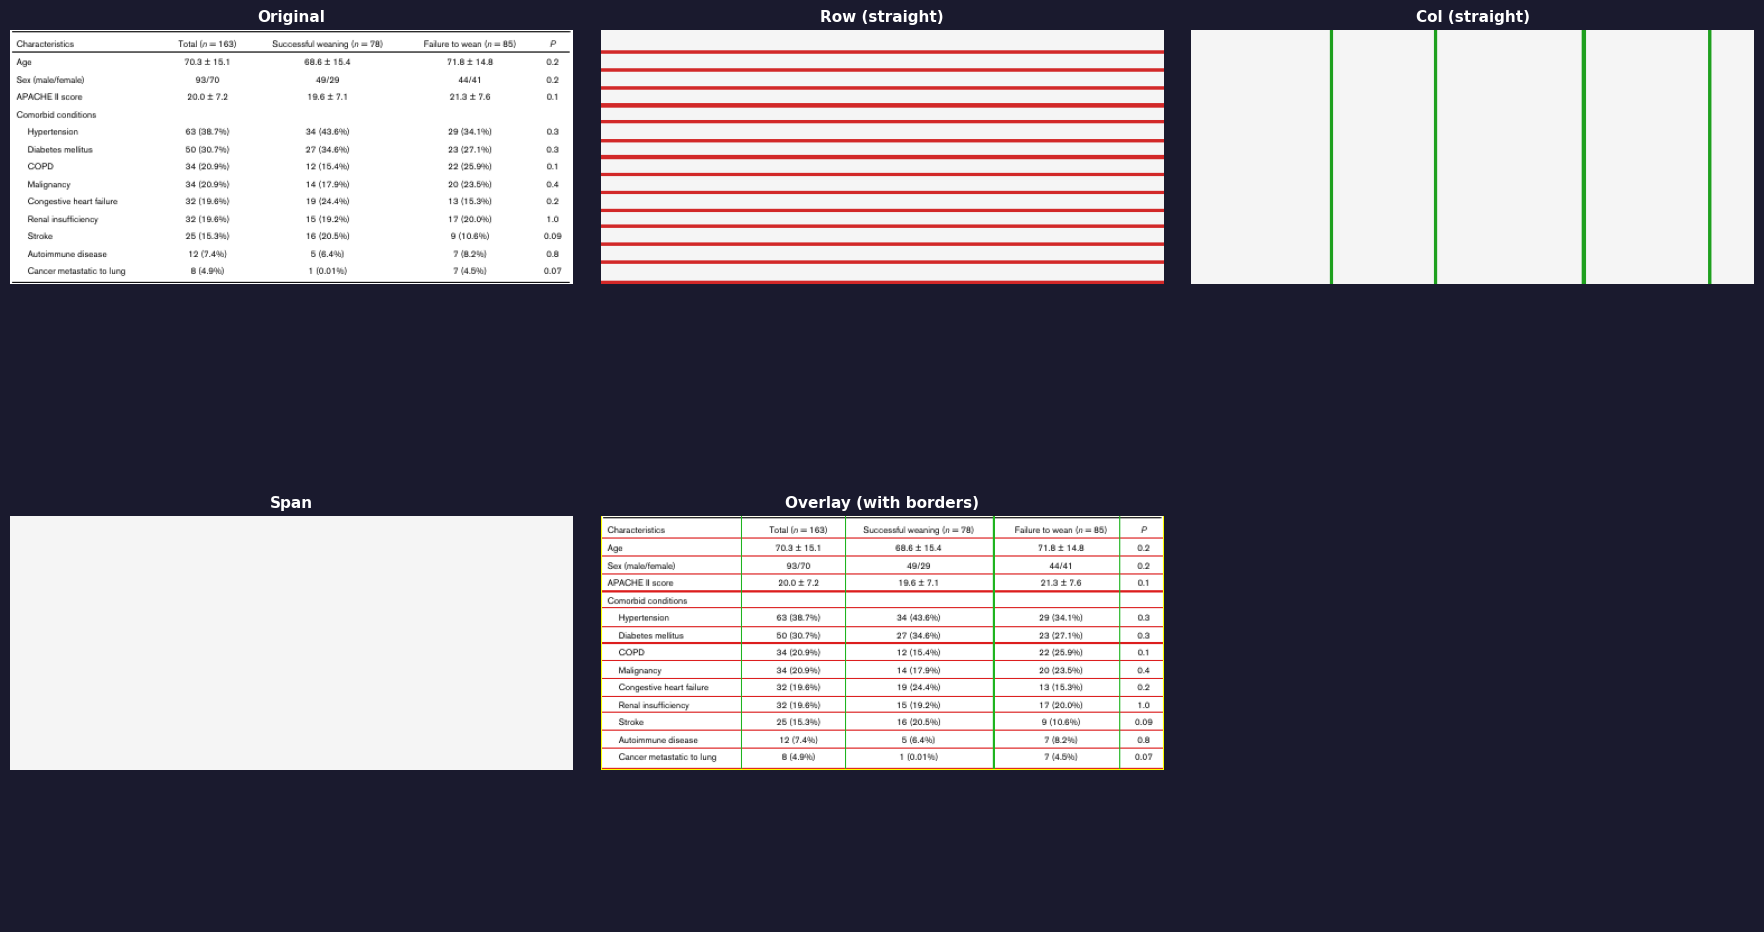

In [50]:
# for i in range(1, 9):
#     img_path = f"/Users/macbookpro14m1pro/Desktop/RagTable/data/test/{i}.jpg"
#     print(f"\n===== Image {i} =====")
#     # Đọc ảnh để ước lượng loại bảng trước (nếu cần)
#     # Có thể gọi thẳng visualize với ngưỡng mặc định,
#     # nhưng ta nên chạy thử cả hai chế độ: full_border và borderless để so sánh.
    
#     # Chạy với ngưỡng mặc định (full_border)
#     print("→ Trying full_border thresholds (0.25, 0.25)")

#     visualize_masks_model(img_path,model_last, device, opt_thresholds)
img_path = "/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/images/sample_00091.png"
visualize_masks_model(img_path,model_last, device, opt_thresholds)



In [16]:
import numpy as np
import cv2
from PIL import Image
import torch
import torchvision.transforms.functional as TF
from dataclasses import dataclass
from typing import List
import re
from pathlib import Path
import matplotlib.pyplot as plt

In [27]:
@dataclass
class Cell:
    row_idx: int
    col_idx: int
    x: int; y: int; w: int; h: int
    is_span: bool = False
    col_span: int = 1
    text: str = ""

In [28]:
def masks_to_cell_boxes(row_mask, col_mask, span_mask, col_header_mask=None, row_header_mask=None,
                        orig_w=384, orig_h=384, img_size=384) -> List[Cell]:
    # Kernel cực lớn để chỉ giữ lại các đường dài (loại bỏ chữ)
    k_h = cv2.getStructuringElement(cv2.MORPH_RECT, (img_size//4, 1))
    k_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, img_size//4))
    k3  = np.ones((3, 3), np.uint8)

    # Tách đường ngang / dọc
    h_lines = cv2.morphologyEx(row_mask * 255, cv2.MORPH_OPEN, k_h)
    v_lines = cv2.morphologyEx(col_mask * 255, cv2.MORPH_OPEN, k_v)

    # Nối đứt nhẹ
    h_lines = cv2.dilate(h_lines, k3, iterations=1)
    v_lines = cv2.dilate(v_lines, k3, iterations=1)

    def mask_to_positions(proj, min_gap=6):
        norm    = proj / (proj.max() + 1e-6)
        is_line = norm > 0.03
        lines   = []
        in_line, start = False, 0
        for i, v in enumerate(is_line):
            if v and not in_line:
                in_line, start = True, i
            elif not v and in_line:
                in_line = False
                mid = (start + i) // 2
                if not lines or mid - lines[-1] >= min_gap:
                    lines.append(mid)
        return lines

    h_proj  = h_lines.sum(axis=1).astype(float)
    v_proj  = v_lines.sum(axis=0).astype(float)

    row_sep = [0] + mask_to_positions(h_proj) + [img_size]
    col_sep = [0] + mask_to_positions(v_proj) + [img_size]

    print(f"  → {len(row_sep)-1} rows, {len(col_sep)-1} cols")

    sx, sy = orig_w / img_size, orig_h / img_size

    num_rows = len(row_sep) - 1
    num_cols = len(col_sep) - 1

    visited = np.zeros((num_rows, num_cols), dtype=bool)

    cells = []
    for r in range(num_rows):
        for c in range(num_cols):
            if visited[r, c]:
                continue
            y1, y2 = row_sep[r], row_sep[r+1]
            x1 = col_sep[c]
            # Xác định xem ô hiện tại có phải header không (dùng col_header_mask)
            is_header = False
            if col_header_mask is not None:
                # Kiểm tra pixel trong vùng ô, nếu > 50% là header
                header_region = col_header_mask[y1:y2, x1:col_sep[c+1]]
                if header_region.size > 0 and header_region.mean() > 0.3:
                    is_header = True
            # Nếu không có col_header_mask, fallback dùng span_mask để quyết định span
            span_region = span_mask[y1:y2, x1:col_sep[c+1]]
            can_span = (span_region.mean() > 0.5) if span_region.size > 0 else False

            # Nếu ô là header hoặc có span, thử mở rộng sang phải
            if is_header or can_span:
                c_end = c
                for cc in range(c+1, num_cols):
                    # Dừng nếu ô tiếp theo đã được thăm
                    if visited[r, cc]:
                        break
                    # Kiểm tra xem có nên span sang ô này không
                    next_x1 = col_sep[cc]
                    next_x2 = col_sep[cc+1]
                    if col_header_mask is not None:
                        next_header_region = col_header_mask[y1:y2, next_x1:next_x2]
                        next_is_header = (next_header_region.size > 0 and next_header_region.mean() > 0.3)
                    else:
                        next_is_header = False
                    next_span_region = span_mask[y1:y2, next_x1:next_x2]
                    next_can_span = (next_span_region.mean() > 0.5) if next_span_region.size > 0 else False

                    # Nếu ô tiếp theo cũng là header hoặc có span, thì mở rộng
                    if (col_header_mask is not None and next_is_header) or (col_header_mask is None and next_can_span):
                        c_end = cc
                    else:
                        break
                # Đánh dấu tất cả các ô trong khoảng c..c_end là đã thăm
                for cc in range(c, c_end+1):
                    visited[r, cc] = True
                x2 = col_sep[c_end+1]
            else:
                # Ô bình thường, không span
                c_end = c
                visited[r, c] = True
                x2 = col_sep[c+1]

            if (x2 - x1) < 6 or (y2 - y1) < 6:
                continue
            rx = int(x1 * sx); ry = int(y1 * sy)
            rw = int((x2 - x1) * sx); rh = int((y2 - y1) * sy)
            cells.append(Cell(
                row_idx=r, col_idx=c,
                x=rx, y=ry, w=rw, h=rh,
                is_span=(c_end > c),  # đánh dấu span nếu đã mở rộng
                col_span=(c_end - c + 1)  # lưu số cột span (sẽ dùng ở cells_to_markdown)
            ))
    return cells

In [19]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    use_textline_orientation=False,
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    lang="en"
)

/Users/macbookpro14m1pro/Desktop/RagTable/python/.venv/lib/python3.10/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/macbookpro14m1pro/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/macbookpro14m1pro/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


In [33]:
import numpy as np
import cv2
import re 
import math

def clean_text(text, col_idx=None):
    text = text.strip()

    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s\.\,\-\(\)%±/=+:;|&']", "", text)
    return text

def fix_percent_96(text):
    return re.sub(r"(\d+\.\d)96\b", r"\1%", text)


def fix_percent_tail(text):
    return re.sub(r"%\d+", "%", text)


def fix_missing_percent(text):
    def repl(match):
        val = match.group(1)
        if "%" not in val and re.match(r"\d+\.\d+", val):
            return f"({val}%)"
        return match.group()
    return re.sub(r"\((.*?)\)", repl, text)

def fix_pm_spacing(text):
    return re.sub(r"(\d)±\s*(\d)", r"\1 ± \2", text)

def normalize_percent(text):
    def repl(match):
        val = float(match.group(1))

        if val < 0.1:
            return match.group()

        return f"{val:.1f}%"
    return re.sub(r"(\d+\.\d+)%", repl, text)

def truncate(val, decimals=2):
    factor = 10 ** decimals
    return math.floor(val * factor) / factor

def normalize_small_percent(text):
    def repl(match):
        val = float(match.group(1))
        if val < 0.1:
            val = truncate(val, 2)
            return f"{val:.2f}%"
        return match.group()
    return re.sub(r"(\d+\.\d+)%", repl, text)

def fix_numbers(text):
    text = fix_percent_tail(text)
    text = fix_percent_96(text)
    # text = fix_missing_percent(text)
    
    text = normalize_small_percent(text)
    text = normalize_percent(text)

    text = fix_pm_spacing(text)

    return text


def crop_and_ocr(image_pil, cells, ocr, upscale=3):
    img_np = np.array(image_pil.convert("RGB"))
    H, W = img_np.shape[:2]

    batch_imgs = []
    valid_cells = []

    for cell in cells:
        pad = max(int(min(cell.w, cell.h) * 0.15), 3)
        x1 = max(0, cell.x - pad); y1 = max(0, cell.y - pad)
        x2 = min(W, cell.x + cell.w + pad); y2 = min(H, cell.y + cell.h + pad)

        crop = img_np[y1:y2, x1:x2]
        if crop.size == 0:
            cell.text = ""
            continue

        gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)
        min_scale = 3.0
        max_scale = 5.0
        h_ratio = max(0.3, min(1.0, cell.h / 100.0)) 
        scale = min_scale + (1 - h_ratio) * (max_scale - min_scale)

        new_w = int(gray.shape[1] * scale)
        new_h = int(gray.shape[0] * scale)

        if cell.col_span > 1:
            debug_img = Image.fromarray(crop)
            debug_img.save(f"debug_span_row{cell.row_idx}_col{cell.col_idx}.png")

        gray = cv2.resize(gray, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
        
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        gray = clahe.apply(gray)

        img_input = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        img_input = resize_with_padding(img_input, target_height=64, target_width=256)

        batch_imgs.append(img_input)
        valid_cells.append(cell)

    results = ocr.predict(batch_imgs)

    for cell, result in zip(valid_cells, results):
        texts = []
        if result:
            if isinstance(result, dict) and "rec_texts" in result:
                texts.extend(result["rec_texts"])
        text = " ".join(t for t in texts if t)

        text = clean_text(text, cell.col_idx)
        text = fix_numbers(text)

        cell.text = text
    return cells

def resize_with_padding(img, target_height, target_width):
    """Resize ảnh giữ nguyên tỉ lệ, thêm viền trắng nếu cần để đạt kích thước mục tiêu."""
    h, w = img.shape[:2]
    ratio = min(target_width / w, target_height / h)
    new_w = int(w * ratio)
    new_h = int(h * ratio)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    # Tạo canvas trắng
    canvas = np.ones((target_height, target_width, 3), dtype=np.uint8) * 255
    # Tính offset để căn giữa
    x_offset = (target_width - new_w) // 2
    y_offset = (target_height - new_h) // 2
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    return canvas

In [34]:
def cells_to_markdown(cells: List[Cell]) -> str:
    if not cells:
        return ""
    max_row = max(c.row_idx for c in cells) + 1
    max_col = max(c.col_idx for c in cells) + 1
    grid = [[""] * max_col for _ in range(max_row)]
    for cell in sorted(cells, key=lambda c: (c.row_idx, c.col_idx)):
        # Đặt text vào ô bắt đầu, và để trống các ô bị span
        grid[cell.row_idx][cell.col_idx] = cell.text
        # Đánh dấu các ô bị span (nếu có) bằng chuỗi rỗng, nhưng không ghi đè
        for offset in range(cell.col_span):
            target_col = cell.col_idx + offset
            if target_col < max_col:
                grid[cell.row_idx][target_col] = cell.text
    lines = []
    for r, row in enumerate(grid):
        lines.append("| " + " | ".join(row) + " |")
        if r == 0:
            lines.append("| " + " | ".join(["---"] * max_col) + " |")
    return "\n".join(lines)

In [82]:
import logging
logging.getLogger('ppocr').setLevel(logging.ERROR)

# Hoặc tắt hoàn toàn
logging.getLogger('ppocr').setLevel(logging.CRITICAL)

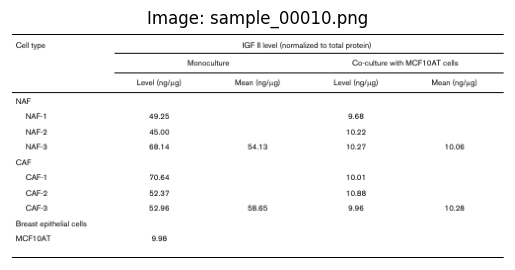

Ảnh gốc: 503×231px


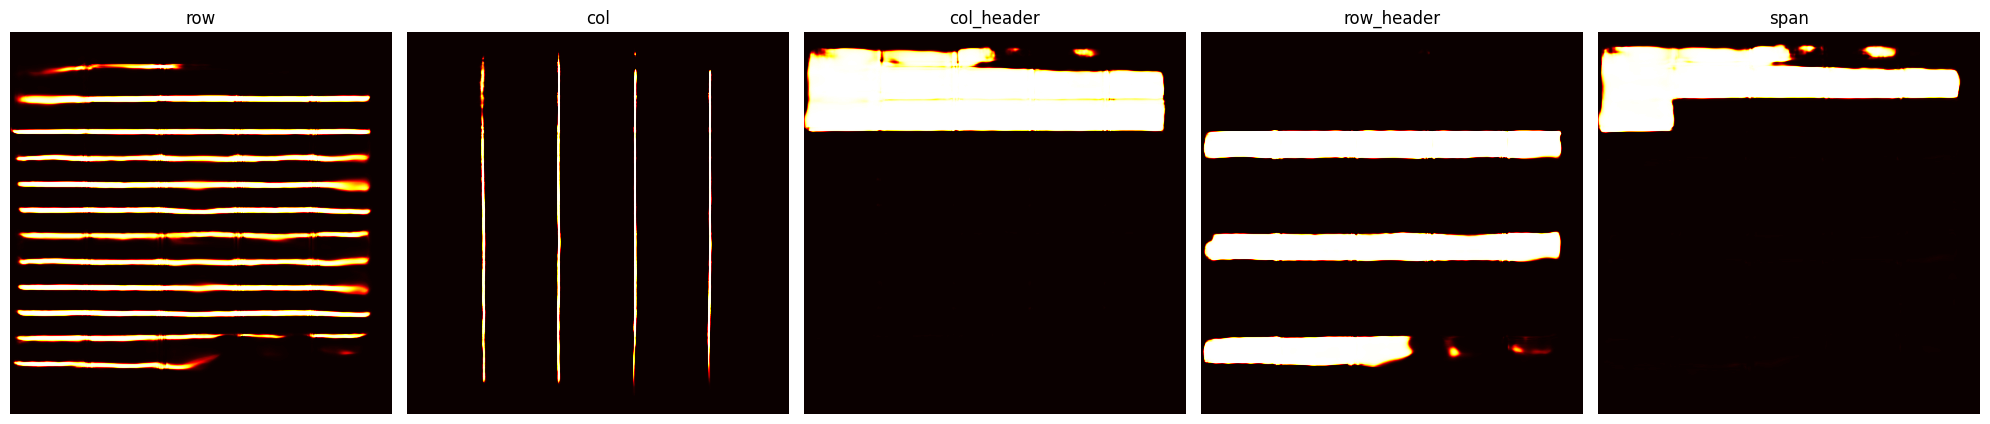

  → 12 rows, 5 cols
Row 0, Col 0, span=4, is_span=True
Row 0, Col 4, span=1, is_span=False
Row 1, Col 0, span=5, is_span=True
Row 2, Col 0, span=1, is_span=False
Row 2, Col 1, span=1, is_span=False
Row 2, Col 2, span=1, is_span=False
Row 2, Col 3, span=1, is_span=False
Row 2, Col 4, span=1, is_span=False
Row 3, Col 0, span=1, is_span=False
Row 3, Col 1, span=1, is_span=False
Tổng cells: 53

=== Markdown Output ===
| Cal s Venocewe IGF it level fxanaloed to stal pranai) Corcuthur with I | Cal s Venocewe IGF it level fxanaloed to stal pranai) Corcuthur with I | Cal s Venocewe IGF it level fxanaloed to stal pranai) Corcuthur with I | Cal s Venocewe IGF it level fxanaloed to stal pranai) Corcuthur with I | th MCF10AT cels |
| --- | --- | --- | --- | --- |
| 1mr )/ve Str eid Laul C 1 sir (9 1 | 1mr )/ve Str eid Laul C 1 sir (9 1 | 1mr )/ve Str eid Laul C 1 sir (9 1 | 1mr )/ve Str eid Laul C 1 sir (9 1 | 1mr )/ve Str eid Laul C 1 sir (9 1 |
| NAF |  |  |  |  |
| NAF-1 | 49.25 |  | 9.68 |  |


In [35]:
def image_to_markdown_v3(image_path, model, device, img_size=384, upscale=3):
    orig_img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = orig_img.size
    print(f"Ảnh gốc: {orig_w}×{orig_h}px")

    # Resize trực tiếp (không padding)
    draft = TF.resize(orig_img, (img_size, img_size),
                      interpolation=TF.InterpolationMode.BILINEAR)
    img_t = TF.to_tensor(draft).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        preds = torch.sigmoid(model(img_t)).squeeze(0).cpu().numpy()

    mask_names = ['row', 'col', 'col_header', 'row_header', 'span']
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    for i, ax in enumerate(axes):
        ax.imshow(preds[i], cmap='hot', interpolation='nearest')
        ax.set_title(mask_names[i])
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('debug_masks.png')  # Lưu lại để phân tích
    plt.show()

    # Ngưỡng cố định 0.5 cho tất cả mask
    row_mask  = (preds[0] > 0.5).astype(np.uint8)
    col_mask  = (preds[1] > 0.5).astype(np.uint8)
    span_mask = (preds[4] > 0.5).astype(np.uint8)

    col_header_mask = (preds[2] > 0.5).astype(np.uint8)  
    row_header_mask = (preds[3] > 0.5).astype(np.uint8)

    cells = masks_to_cell_boxes(row_mask, col_mask, span_mask,
                               col_header_mask, row_header_mask,
                               orig_w, orig_h, img_size)
    for cell in cells[:10]:
        print(f"Row {cell.row_idx}, Col {cell.col_idx}, span={cell.col_span}, is_span={cell.is_span}")

    print(f"Tổng cells: {len(cells)}")

    # OCR
    cells = crop_and_ocr(orig_img, cells, ocr, upscale=upscale)

    # Xuất Markdown
    md = cells_to_markdown(cells)
    return md, cells

# ── Demo chạy thử ───────────────────────────────────────
TEST_IMG_DIR = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/images")
test_images = list(TEST_IMG_DIR.glob("*.png"))
if not test_images:
    test_images = list(TEST_IMG_DIR.glob("*.jpg"))

# random_img_path = random.choice(test_images)
random_img_path = TEST_IMG_DIR / "sample_00010.png"
img = Image.open(random_img_path)
plt.imshow(img)
plt.axis("off")
plt.title(f"Image: {random_img_path.name}")
plt.show()

md, cells = image_to_markdown_v3(random_img_path, model_last, device, img_size=384, upscale=3)
print("\n=== Markdown Output ===")
print(md)

Ảnh gốc: 503×243px
  → 15 rows, 4 cols
Tổng cells: 60


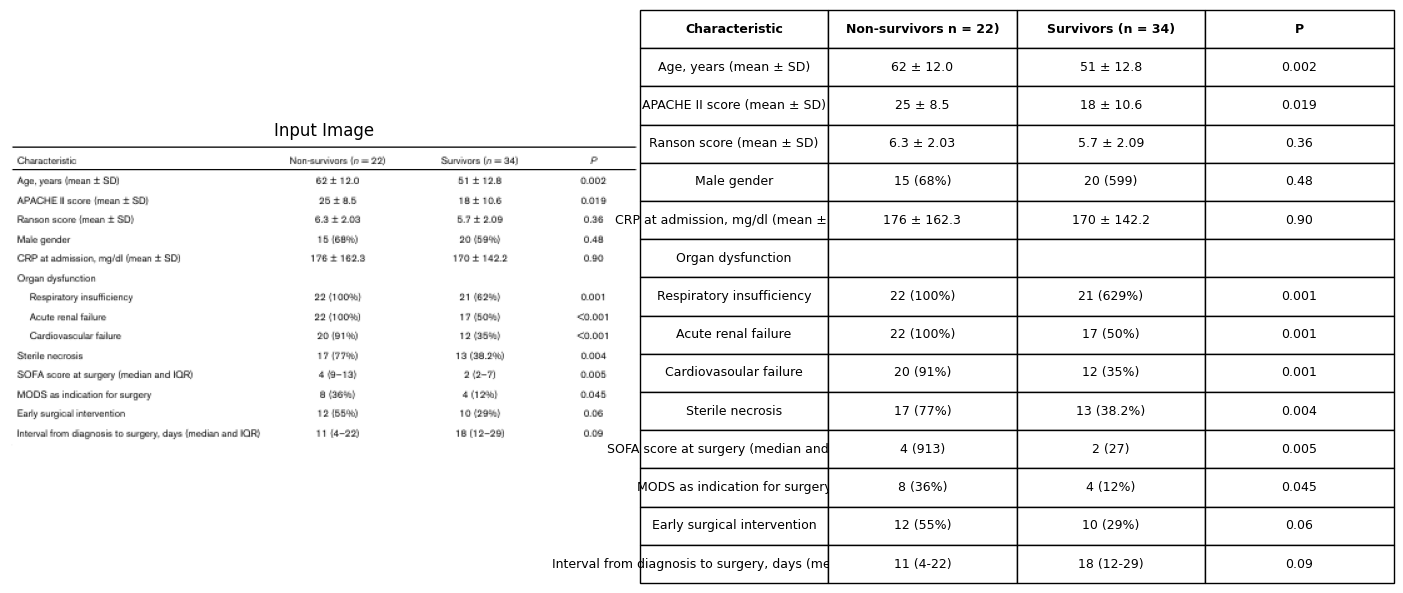

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from io import StringIO
import re

# ─────────────────────────────────────────────
# Fix lỗi OCR (%, ký tự đặc biệt hay sai)
# ─────────────────────────────────────────────
def clean_ocr_text(md):
    md = md.replace("％", "%")   # full-width %
    md = md.replace("�", "")     # ký tự lỗi
    md = md.replace("—", "-")
    
    # fix lỗi kiểu: 10 % -> 10%
    md = re.sub(r'(\d)\s+%', r'\1%', md)

    # fix lỗi math hay gặp
    md = md.replace("H20", "H2O")
    md = md.replace("m2", "m²")

    return md


# ─────────────────────────────────────────────
# Convert Markdown → DataFrame
# ─────────────────────────────────────────────
def md_to_df(md):
    md = clean_ocr_text(md)

    lines = md.strip().split("\n")
    lines = [line.strip() for line in lines if line.strip()]

    # bỏ dòng separator |---|
    lines = [l for l in lines if not re.match(r'^\|\s*-+', l)]

    data = []
    for line in lines:
        row = [cell.strip() for cell in line.split("|")[1:-1]]
        data.append(row)

    df = pd.DataFrame(data[1:], columns=data[0])
    return df


# ─────────────────────────────────────────────
# Vẽ so sánh: ảnh vs bảng
# ─────────────────────────────────────────────
def visualize_compare(image_path, md):
    img = Image.open(image_path)

    try:
        df = md_to_df(md)
    except:
        print("Markdown lỗi format, fallback sang text")
        df = None

    plt.figure(figsize=(14,6))

    # ───── Ảnh ─────
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    # ───── Table ─────
    plt.subplot(1,2,2)
    plt.axis("off")

    if df is not None:
        table = plt.table(
            cellText=df.values,
            colLabels=df.columns,
            loc='center',
            cellLoc='center'
        )

        # 🔥 Font + scale
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1.2, 1.8)

        # 🔥 Wrap text + padding
        for (row, col), cell in table.get_celld().items():
            cell.set_text_props(wrap=True)
            cell.set_height(0.08)

            # header đậm hơn
            if row == 0:
                cell.set_text_props(weight='bold')

    else:
        plt.text(0, 1, md, family='monospace', va='top')

    plt.tight_layout()
    plt.show()

image_path = "/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/images/sample_00010.png"
# ─────────────────────────────────────────────
# 🔥 DEMO Markdown (có lỗi giống OCR)
# ─────────────────────────────────────────────
md, cells = image_to_markdown_v3(image_path, model_last, device)

visualize_compare(image_path, md)

In [24]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import time
from rapidfuzz import fuzz
import re

# 1. CÁC HÀM TÍNH ĐIỂM (Giữ nguyên chuẩn mực đánh giá)
def markdown_to_grid(md_str):
    if not md_str: return []
    lines = [l.strip() for l in md_str.split('\n') if l.strip() and '|' in l and '---' not in l]
    grid = [list(map(str.strip, l.strip('|').split('|'))) for l in lines]
    return grid

def super_clean(text):
    if not text: return ""
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

def calculate_cell_accuracy(md_pred, md_gt):
    grid_p = markdown_to_grid(md_pred)
    grid_g = markdown_to_grid(md_gt)
    
    if not grid_g: return 0.0
    if not grid_p: return 0.0 

    rows_g = len(grid_g)
    cols_g = len(grid_g[0])
    total_cells_gt = rows_g * cols_g
    
    match_count = 0
    
    for r in range(rows_g):
        for c in range(cols_g):
            try:
                p_raw = grid_p[r][c] if r < len(grid_p) and c < len(grid_p[0]) else ""
                g_raw = grid_g[r][c]
                
                p_text = super_clean(p_raw)
                g_text = super_clean(g_raw)
                
                if not p_text and not g_text:
                    match_count += 1
                elif p_text and g_text:
                    if p_text == g_text or fuzz.ratio(p_text, g_text) > 80:
                        match_count += 1
            except Exception:
                continue 
                
    return (match_count / total_cells_gt) * 100

In [25]:
# 2. CẤU HÌNH ĐƯỜNG DẪN & CHUẨN BỊ DỮ LIỆU
GT_FOLDER = "/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/markdown_gt"
IMG_FOLDER = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/images")

# Lấy 200 mẫu (Nếu bạn muốn chạy HẾT toàn bộ thư mục, hãy xóa "[:200]")
SAMPLES = list(IMG_FOLDER.glob("*.png"))[:200]
if not SAMPLES:
    SAMPLES = list(IMG_FOLDER.glob("*.jpg"))[:200]

results = []

# 3. VÒNG LẶP ĐÁNH GIÁ CHÍNH
print(f"\n🚀 Bắt đầu chạy full đánh giá {len(SAMPLES)} samples trên Model U-Net...")
start_time = time.time()

for idx, sample_path in enumerate(tqdm(SAMPLES, desc="Đang xử lý")):
    filename = sample_path.stem
    gt_file = Path(GT_FOLDER) / f"{filename}.md"
    
    # Bỏ qua nếu không có file Ground Truth tương ứng
    if not gt_file.exists():
        continue
        
    try:
        t_start = time.time()
        unet_md, cells = image_to_markdown_v3(
            str(sample_path),
            model_best,            
            device,
            img_size=384,         
            upscale=3.0
        )
        t_end = time.time()
        elapsed = t_end - t_start
        
        # Đọc Ground Truth
        with open(gt_file, 'r', encoding='utf-8') as f:
            gt_md = f.read()
            
        # Tính điểm Accuracy
        acc = calculate_cell_accuracy(unet_md, gt_md)
        
        results.append({
            "index": idx,
            "filename": filename,
            "accuracy": acc,
            "time_sec": round(elapsed, 2),
            "num_cells": len(cells) if cells else 0
        })
    except Exception as e:
        print(f"⚠️ Lỗi tại file {filename}: {e}")

# 4. TỔNG HỢP VÀ XUẤT BÁO CÁO
df_results = pd.DataFrame(results)
avg_acc = df_results['accuracy'].mean()
total_time = time.time() - start_time

print("\n" + "="*45)
print(f"📊 KẾT QUẢ TỔNG HỢP: MODEL U-NET ({len(df_results)} SAMPLES)")
print("="*45)
print(f"➤ Độ chính xác trung bình (Cell-level) : {avg_acc:.2f}%")
print(f"➤ Số file đạt xuất sắc (> 90%)         : {len(df_results[df_results['accuracy'] >= 90])}")
print(f"➤ Số file bị lỗi cấu trúc (< 50%)      : {len(df_results[df_results['accuracy'] < 50])}")
print(f"➤ Tổng thời gian chạy                  : {total_time:.2f} giây")
print(f"➤ Tốc độ trung bình                    : {total_time/len(df_results):.2f} giây/ảnh")
print("="*45)

# Lưu file kết quả để vẽ biểu đồ chéo với file của Docling
df_results.to_csv("unet_pipeline_eval_results_v3.csv", index=False)
print("✅ Đã lưu kết quả chi tiết vào file: unet_pipeline_eval_results_v3.csv")


🚀 Bắt đầu chạy full đánh giá 200 samples trên Model U-Net...


Đang xử lý:   0%|          | 0/200 [00:00<?, ?it/s]

Ảnh gốc: 241×165px
  → 14 rows, 5 cols
Tổng cells: 70


Đang xử lý:   0%|          | 1/200 [00:18<1:01:50, 18.65s/it]

Ảnh gốc: 486×408px
  → 29 rows, 11 cols
Tổng cells: 319


...

Ảnh gốc: 486×186px
  → 13 rows, 5 cols
Tổng cells: 65


Đang xử lý: 100%|█████████▉| 199/200 [41:19<00:09,  9.50s/it]

Ảnh gốc: 238×255px
  → 18 rows, 5 cols
Tổng cells: 90


Đang xử lý: 100%|██████████| 200/200 [41:31<00:00, 12.46s/it]


📊 KẾT QUẢ TỔNG HỢP: MODEL U-NET (200 SAMPLES)
➤ Độ chính xác trung bình (Cell-level) : 66.66%
➤ Số file đạt xuất sắc (> 90%)         : 87
➤ Số file bị lỗi cấu trúc (< 50%)      : 58
➤ Tổng thời gian chạy                  : 2491.68 giây
➤ Tốc độ trung bình                    : 12.46 giây/ảnh
✅ Đã lưu kết quả chi tiết vào file: unet_pipeline_eval_results_v3.csv
